<a href="https://colab.research.google.com/github/ekttd/VAST-Challenge/blob/main/sunday_crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ воскресенья на преступление.
Предполагаемое время преступления - 11:45-12:00  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [83]:
fri_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Fri.csv"
sat_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sat.csv"
sun_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sun.csv"
df_fri = pd.read_csv(fri_url)
df_sat = pd.read_csv(sat_url)
df_sun = pd.read_csv(sun_url)
df_sun.head()

,Timestamp,from,to,location
0,2014-6-08 08:01:05,1401601,839736,Kiddie Land
1,2014-6-08 08:01:16,1169163,600636,Entry Corridor
2,2014-6-08 08:01:16,1169163,1561994,Entry Corridor
3,2014-6-08 08:01:16,1169163,864634,Entry Corridor
4,2014-6-08 08:01:16,1169163,577530,Entry Corridor


In [ ]:
print(f"\nУникальные значения в location:")
print(df_sun['location'].unique())


Уникальные значения в location:
['Kiddie Land' 'Entry Corridor' 'Tundra Land' 'Wet Land' 'Coaster Alley']


Фильтруем только сообщения из Wet Land там предположительно произошло преступление

In [ ]:
wet_land_df = df_sun[df_sun['location'] == 'Wet Land'].copy()

print(f"\nВсего сообщений в воскресенье: {len(df_sun)}")
print(f"Сообщений из Wet Land: {len(wet_land_df)}")


Всего сообщений в воскресенье: 1548724
Сообщений из Wet Land: 598728


In [ ]:
wet_land_df['datetime'] = pd.to_datetime(wet_land_df['Timestamp'])
wet_land_df['time_rounded'] = wet_land_df['datetime'].dt.floor('1min')

In [ ]:
external_msgs = wet_land_df[wet_land_df['to'] == 'external'].copy()
service_msgs = wet_land_df[wet_land_df['to'] == "839736"].copy()
print(f"Сообщений в external из Wet Land: {len(external_msgs)}")
print(f"Сообщений в 839736 из Wet Land: {len(service_msgs)}")

Сообщений в external из Wet Land: 14794
Сообщений в 839736 из Wet Land: 33048


In [ ]:
external_by_min = external_msgs.groupby('time_rounded').size().reset_index(name='count')
service_by_min = service_msgs.groupby('time_rounded').size().reset_index(name='count')
start_time = pd.Timestamp('2014-6-08 08:00:00')
end_time = pd.Timestamp('2014-6-08 23:00:00')
all_times = pd.date_range(start_time, end_time, freq='1min')


external_full = pd.DataFrame({'time_rounded': all_times})
external_full = external_full.merge(external_by_min, on='time_rounded', how='left').fillna(0)

service_full = pd.DataFrame({'time_rounded': all_times})
service_full = service_full.merge(service_by_min, on='time_rounded', how='left').fillna(0)

In [ ]:
def get_time_labels(times, step_minutes=30):
    labels = []
    for i, t in enumerate(times):
        if i % step_minutes == 0:
            labels.append(t.strftime('%H:%M'))
        else:
            labels.append('')
    return labels

/tmp/ipykernel_742/3206784852.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ax.set_xticks(pd.date_range(start_time, end_time, freq='1H'))
/tmp/ipykernel_742/3206784852.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ax.set_xticklabels([t.strftime('%H:%M') for t in pd.date_range(start_time, end_time, freq='1H')])
/tmp/ipykernel_742/3206784852.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ax.set_xticks(pd.date_range(start_time, end_time, freq='1H'))
/tmp/ipykernel_742/3206784852.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ax.set_xticklabels([t.strftime('%H:%M') for t in pd.date_range(start_time, end_time, freq='1H')])


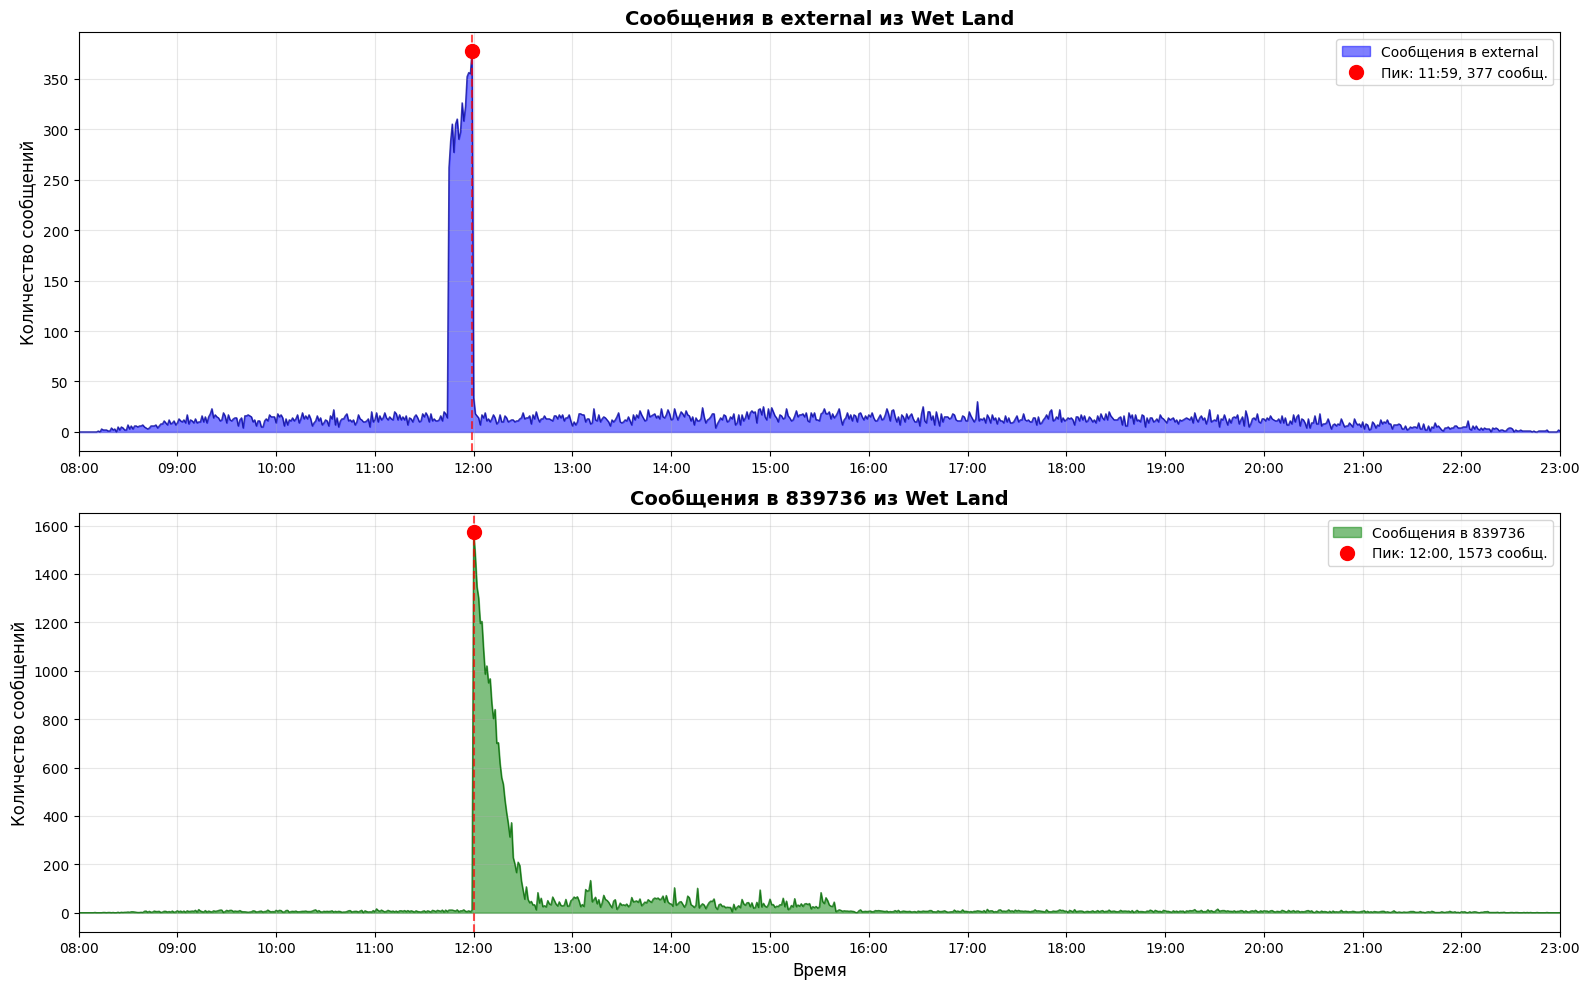

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# cообщения в external
ax1.fill_between(external_full['time_rounded'], external_full['count'],
                 alpha=0.5, color='blue', label='Сообщения в external')
ax1.plot(external_full['time_rounded'], external_full['count'],
         color='darkblue', linewidth=1, alpha=0.7)
ax1.set_title('Сообщения в external из Wet Land', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество сообщений', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# пик external
ext_peak_idx = external_full['count'].idxmax()
ext_peak_time = external_full.loc[ext_peak_idx, 'time_rounded']
ext_peak_val = external_full.loc[ext_peak_idx, 'count']
ax1.plot(ext_peak_time, ext_peak_val, 'ro', markersize=10,
         label=f'Пик: {ext_peak_time.strftime("%H:%M")}, {ext_peak_val:.0f} сообщ.')
ax1.axvline(x=ext_peak_time, color='red', linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# cообщения в 839736
ax2.fill_between(service_full['time_rounded'], service_full['count'],
                 alpha=0.5, color='green', label='Сообщения в 839736')
ax2.plot(service_full['time_rounded'], service_full['count'],
         color='darkgreen', linewidth=1, alpha=0.7)
ax2.set_title('Сообщения в 839736 из Wet Land',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество сообщений', fontsize=12)
ax2.set_xlabel('Время', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# пик 839736
serv_peak_idx = service_full['count'].idxmax()
serv_peak_time = service_full.loc[serv_peak_idx, 'time_rounded']
serv_peak_val = service_full.loc[serv_peak_idx, 'count']
ax2.plot(serv_peak_time, serv_peak_val, 'ro', markersize=10,
         label=f'Пик: {serv_peak_time.strftime("%H:%M")}, {serv_peak_val:.0f} сообщ.')
ax2.axvline(x=serv_peak_time, color='red', linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

for ax in [ax1, ax2]:
    ax.set_xlim(start_time, end_time)
    ax.set_xticks(pd.date_range(start_time, end_time, freq='1H'))
    ax.set_xticklabels([t.strftime('%H:%M') for t in pd.date_range(start_time, end_time, freq='1H')])

plt.tight_layout()
plt.show()

Предполагается, что люди в парке сразу после преступления (примерно в 11:40) начали писать в external, рассказать друзьям/в соц сетях о том, что произошло. И только после этого люди обращаются в службу поддержки парка (839736).   


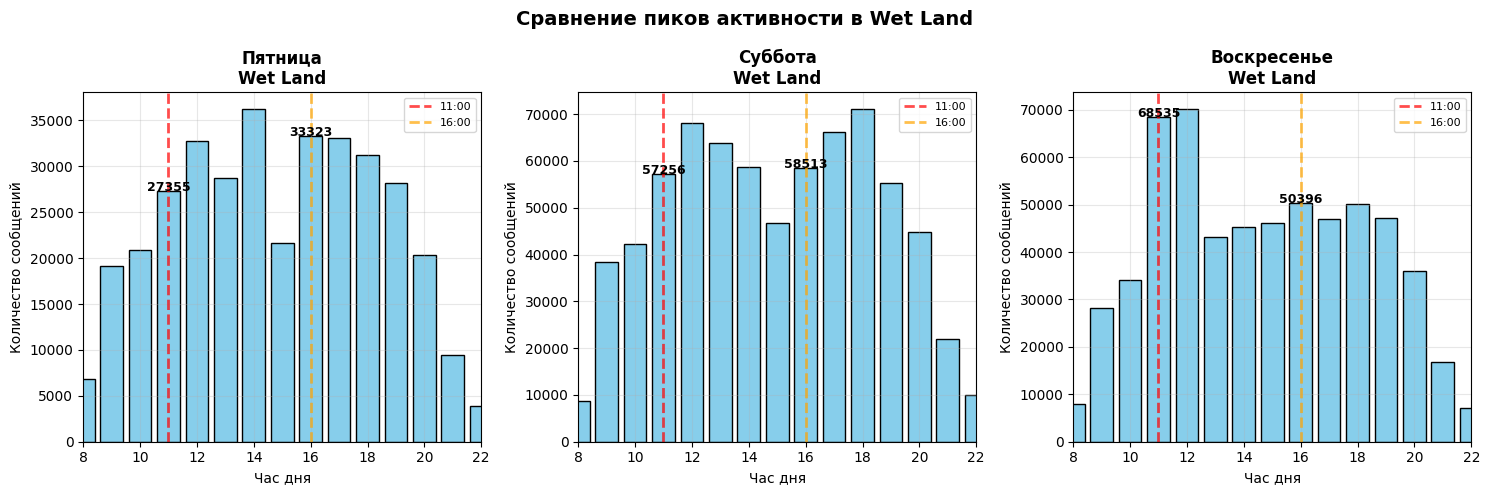

In [85]:
# Загружаем данные для всех дней
df_fri = pd.read_csv(fri_url)
df_sat = pd.read_csv(sat_url)
df_sun = pd.read_csv(sun_url)

# Добавляем колонку с часом
for df in [df_fri, df_sat, df_sun]:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['hour'] = df['Timestamp'].dt.hour

days = ['Пятница', 'Суббота', 'Воскресенье']
dfs = [df_fri, df_sat, df_sun]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (day_name, df_day) in enumerate(zip(days, dfs)):
    # Фильтруем только Wet Land
    coaster = df_day[df_day['location'] == 'Wet Land']
    # Группируем по часам
    hourly = coaster.groupby('hour').size().reindex(range(24), fill_value=0)

    ax = axes[idx]
    ax.bar(hourly.index, hourly.values, color='skyblue', edgecolor='black')
    ax.axvline(x=11, color='red', linestyle='--', alpha=0.7, linewidth=2, label='11:00')
    ax.axvline(x=16, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='16:00')
    ax.set_title(f'{day_name}\nWet Land', fontsize=12, fontweight='bold')
    ax.set_xlabel('Час дня', fontsize=10)
    ax.set_ylabel('Количество сообщений', fontsize=10)
    ax.set_xlim(8, 22)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

    # Добавляем значения на пиках
    ax.text(11, hourly[11] + 5, f'{hourly[11]}', ha='center', fontsize=9, fontweight='bold')
    ax.text(16, hourly[16] + 5, f'{hourly[16]}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение пиков активности в Wet Land',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## В пятницу и субботу есть два пика активности - в +-12 и в +-18. В воскресенье второй пик пропадает, тк (по нашей теории) в первой половине дня было совершено преступление, соответственно во второй половине дня активности могли быть отменены или люди покинули территорию парка.